# Instructions for running it


```
python3.11 -m venv venv
source venv/bin/activate

pip install jupyter ipykernel neat-python graphviz matplotlib numpy scikit-learn tqdm gymnasium "gymnasium[classic-control]" swig "gymnasium[box2d]" mujoco "gymnasium[mujoco]"

python -m ipykernel install --user --name=venv
```


In [1]:
import numpy as np
import gymnasium as gym
import os
import matplotlib.pyplot as plt
import neat
import tqdm
import random
import copy

In [9]:
def run_experiment(eval_genomes, config_path, num_runs, num_generations, output_postprocessing):
    config = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                         neat.DefaultSpeciesSet, neat.DefaultStagnation,
                         config_path)
    
    history_best_fitness = np.zeros((num_runs, num_generations))
    history_avg_fitness = np.zeros((num_runs, num_generations))
    history_min_fitness = np.zeros((num_runs, num_generations))
    best_genome = None
    max_fitness_ever = None

    for run_idx in range(num_runs):
        print(f"Run {run_idx + 1}/{num_runs}")
        
        p = neat.Population(config)
        
        for gen in tqdm.tqdm(range(num_generations)):
            winner_of_gen = p.run(eval_genomes, 1)
            
            current_fitnesses = []
            for g in p.population.values():
                if g.fitness is not None:
                    current_fitnesses.append(g.fitness)
            
            history_best_fitness[run_idx, gen] = max(current_fitnesses)
            history_avg_fitness[run_idx, gen] = np.mean(current_fitnesses)
            history_min_fitness[run_idx, gen] = min(current_fitnesses)

            if max_fitness_ever is None or winner_of_gen.fitness > max_fitness_ever:
                max_fitness_ever = winner_of_gen.fitness
                best_genome = copy.deepcopy(winner_of_gen)

    plot_best = np.mean(history_best_fitness, axis=0)
    plot_avg = np.mean(history_avg_fitness, axis=0)
    plot_min = np.mean(history_min_fitness, axis=0)
    return (plot_best, plot_avg, plot_min), best_genome, config

def gym_loop(state, net, env, output_postprocessing):
    done = False
    total_reward = 0
    
    while not done:
        output = net.activate(state)
        output = output_postprocessing(output)
        state, reward, terminated, truncated, info = env.step(output)
        total_reward += reward
        done = terminated or truncated
    
    return total_reward

def create_eval_genomes(gym_name, individual_environment_iterations, output_postprocessing):
    def eval_genomes(genomes, config):
        env = gym.make(gym_name)
        ran = random.uniform(1.0, 10000.0)
        for genome_id, genome in genomes:
            net = neat.nn.FeedForwardNetwork.create(genome, config)
            averaged_reward = 0
            
            for s in range(individual_environment_iterations):
                ss = int(s*ran)
                state, _ = env.reset(seed=ss)
                total_reward = gym_loop(state, net, env, output_postprocessing)
                averaged_reward += total_reward / individual_environment_iterations
                
            genome.fitness = averaged_reward      
        
        env.close()

    return eval_genomes
    
def show_gym(gym_name, winner_genome, config, output_postprocessing):
    env = gym.make(gym_name, render_mode='human')
    net = neat.nn.FeedForwardNetwork.create(winner_genome, config)
    
    state, _ = env.reset()
    total_reward = gym_loop(state, net, env, output_postprocessing)

    print(f"total_reward = {total_reward}")
    env.close()

# CartPole-v1

full settings of this algorithm can be found in ./config-cartpole.

```
num_hidden              = 0
num_inputs              = 4
num_outputs             = 2
```

This problem was easy to solve for NEAT. Graph converged to maximum value very quickly.

In [3]:
GYM_NAME = 'CartPole-v1'
def carpole_output_postprocessing(output):
    return np.argmax(output)

NUM_RUNS = 3
GENERATIONS = 40
INDIVIDUAL_ENVIRONMENT_ITERATIONS = 5
CONFIG_PATH = os.path.join('.', 'config-cartpole')
OUTPUT_POSTPROCESSING = carpole_output_postprocessing

In [10]:
eval_genomes = create_eval_genomes(GYM_NAME, INDIVIDUAL_ENVIRONMENT_ITERATIONS, OUTPUT_POSTPROCESSING)
(plot_best, plot_avg, plot_min), best_cartpole, cartpole_config_obj = run_experiment(eval_genomes, CONFIG_PATH, NUM_RUNS, GENERATIONS, OUTPUT_POSTPROCESSING)

Run 1/3


100%|██████████| 40/40 [01:46<00:00,  2.67s/it]


Run 2/3


100%|██████████| 40/40 [01:41<00:00,  2.53s/it]


Run 3/3


100%|██████████| 40/40 [01:49<00:00,  2.73s/it]


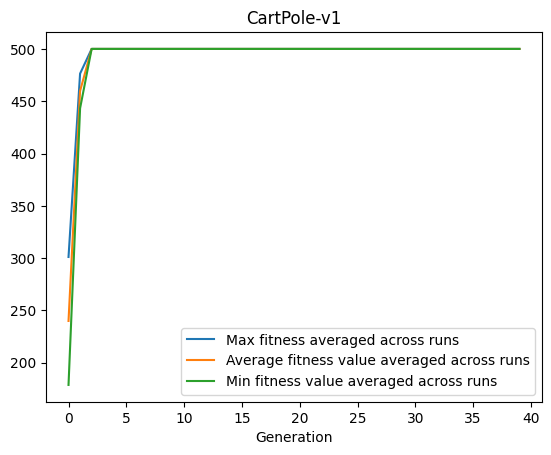

In [11]:
plt.plot(range(GENERATIONS), plot_best, label="Max fitness averaged across runs")
plt.plot(range(GENERATIONS), plot_avg, label="Average fitness value averaged across runs")
plt.plot(range(GENERATIONS), plot_min, label="Min fitness value averaged across runs")
plt.title(GYM_NAME)
plt.xlabel('Generation')
plt.legend()
plt.show()

In [12]:
print('\nBest genome:\n{!s}'.format(best_cartpole))


Best genome:
Key: 241
Fitness: 500.0
Nodes:
	0 DefaultNodeGene(key=0, bias=-1.0901013241587199, response=1.0, activation=relu, aggregation=sum, time_constant=1.0)
	1 DefaultNodeGene(key=1, bias=0.17283635292597727, response=1.0, activation=relu, aggregation=sum, time_constant=1.0)
Connections:
	DefaultConnectionGene(key=(-4, 0), innovation=7, weight=-1.141295333710644, enabled=True)
	DefaultConnectionGene(key=(-4, 1), innovation=8, weight=0.8533284845449145, enabled=True)
	DefaultConnectionGene(key=(-3, 0), innovation=5, weight=0.5822173781731209, enabled=True)
	DefaultConnectionGene(key=(-3, 1), innovation=6, weight=1.6043206789898596, enabled=True)
	DefaultConnectionGene(key=(-2, 0), innovation=3, weight=-1.0116323536442533, enabled=True)
	DefaultConnectionGene(key=(-2, 1), innovation=4, weight=0.9957804405623083, enabled=True)
	DefaultConnectionGene(key=(-1, 0), innovation=1, weight=-0.22897488342587563, enabled=True)
	DefaultConnectionGene(key=(-1, 1), innovation=2, weight=1.06721

In [13]:
show_gym(GYM_NAME, best_cartpole, cartpole_config_obj, OUTPUT_POSTPROCESSING)

total_reward = 500.0


# BipedalWalker-v3

full settings of this algorithm can be found in ./config-bipedalwalker.

Here it was a bit tricky to get it right. Quite good result I got with:

```
initial_connection      = full_nodirect

num_hidden              = 50
num_inputs              = 24
num_outputs             = 4
```

additional hidden layer with some connections, improved the result and the walker could accually walk.

Looking at the graph, it shows that the results weren't perfect, but my robot found some weird way to walk :). Probably with higher population and more generations, it should improve.


In [14]:
GYM_NAME = 'BipedalWalker-v3'
def bipedalwalker_output_postprocessing(output):
    return np.tanh(output)
    
NUM_RUNS = 2
GENERATIONS = 40
INDIVIDUAL_ENVIRONMENT_ITERATIONS = 2
CONFIG_PATH = os.path.join('.', 'config-bipedalwalker')
OUTPUT_POSTPROCESSING = bipedalwalker_output_postprocessing


In [15]:
eval_genomes = create_eval_genomes(GYM_NAME, INDIVIDUAL_ENVIRONMENT_ITERATIONS, OUTPUT_POSTPROCESSING)
(plot_best, plot_avg, plot_min), best_bipedalwalker, bipedalwalker_config_obj = run_experiment(eval_genomes, CONFIG_PATH, NUM_RUNS, GENERATIONS, OUTPUT_POSTPROCESSING)

Run 1/2


100%|██████████| 40/40 [11:03<00:00, 16.60s/it]


Run 2/2


100%|██████████| 40/40 [14:32<00:00, 21.82s/it]


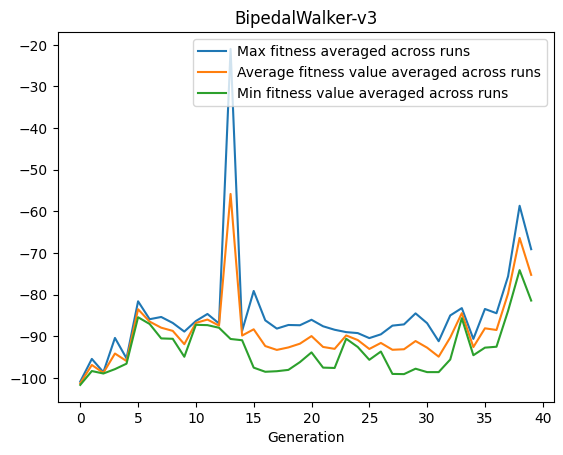

In [16]:
plt.plot(range(GENERATIONS), plot_best, label="Max fitness averaged across runs")
plt.plot(range(GENERATIONS), plot_avg, label="Average fitness value averaged across runs")
plt.plot(range(GENERATIONS), plot_min, label="Min fitness value averaged across runs")
plt.title(GYM_NAME)
plt.xlabel('Generation')
plt.legend()
plt.show()

In [17]:
print('\nBest genome:\n{!s}'.format(best_bipedalwalker))


Best genome:
Key: 899
Fitness: 40.432948960698695
Nodes:
	0 DefaultNodeGene(key=0, bias=0.7124718004552526, response=1.0, activation=tanh, aggregation=sum, time_constant=1.0)
	1 DefaultNodeGene(key=1, bias=-0.8053705855968258, response=1.0, activation=tanh, aggregation=sum, time_constant=1.0)
	2 DefaultNodeGene(key=2, bias=-0.19683669225092715, response=1.0, activation=tanh, aggregation=sum, time_constant=1.0)
	3 DefaultNodeGene(key=3, bias=-0.7120223768577612, response=1.0, activation=tanh, aggregation=sum, time_constant=1.0)
	2504 DefaultNodeGene(key=2504, bias=1.6511928163216474, response=1.0, activation=tanh, aggregation=sum, time_constant=1.0)
	2505 DefaultNodeGene(key=2505, bias=-1.9927109675479813, response=1.0, activation=tanh, aggregation=sum, time_constant=1.0)
	2506 DefaultNodeGene(key=2506, bias=0.9543022511695011, response=1.0, activation=tanh, aggregation=sum, time_constant=1.0)
	2507 DefaultNodeGene(key=2507, bias=0.22349145767664338, response=1.0, activation=tanh, aggr

In [20]:
show_gym(GYM_NAME, best_bipedalwalker, bipedalwalker_config_obj, OUTPUT_POSTPROCESSING)

total_reward = -88.93083620467253


# HalfCheetah-v5

full settings of this algorithm can be found in ./config-halfcheetah.

This simulation was really easy to train. Only needed 20 generations to make it run.

```
num_hidden              = 32
num_inputs              = 17
num_outputs             = 6
```

I added some hidden layers, because it resulted in faster training.

In [22]:
GYM_NAME = 'HalfCheetah-v5'
def halfcheetah_output_postprocessing(output):
    return np.array(output, dtype=np.float32)
    
NUM_RUNS = 2
GENERATIONS = 20
INDIVIDUAL_ENVIRONMENT_ITERATIONS = 2
CONFIG_PATH = os.path.join('.', 'config-halfcheetah')
OUTPUT_POSTPROCESSING = halfcheetah_output_postprocessing


In [23]:
eval_genomes = create_eval_genomes(GYM_NAME, INDIVIDUAL_ENVIRONMENT_ITERATIONS, OUTPUT_POSTPROCESSING)
(plot_best, plot_avg, plot_min), best_halfcheetah, halfcheetah_config_obj = run_experiment(eval_genomes, CONFIG_PATH, NUM_RUNS, GENERATIONS, OUTPUT_POSTPROCESSING)

Run 1/2


100%|██████████| 20/20 [02:50<00:00,  8.52s/it]


Run 2/2


100%|██████████| 20/20 [02:49<00:00,  8.46s/it]


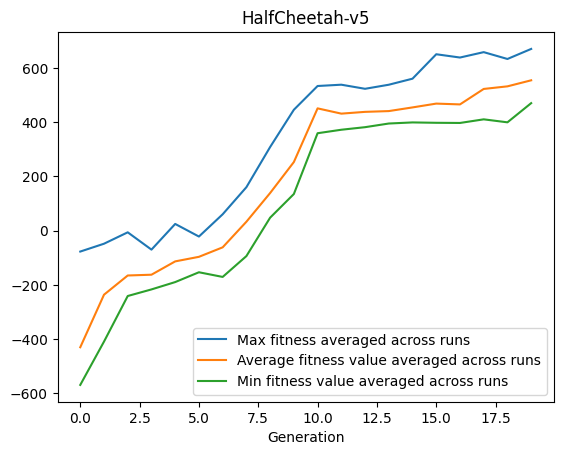

In [24]:
plt.plot(range(GENERATIONS), plot_best, label="Max fitness averaged across runs")
plt.plot(range(GENERATIONS), plot_avg, label="Average fitness value averaged across runs")
plt.plot(range(GENERATIONS), plot_min, label="Min fitness value averaged across runs")
plt.title(GYM_NAME)
plt.xlabel('Generation')
plt.legend()
plt.show()

In [25]:
print('\nBest genome:\n{!s}'.format(best_halfcheetah))


Best genome:
Key: 111
Fitness: 724.6364565103513
Nodes:
	0 DefaultNodeGene(key=0, bias=-0.36755808063607437, response=1.0, activation=tanh, aggregation=sum, time_constant=1.0)
	1 DefaultNodeGene(key=1, bias=1.0958982721688255, response=1.0, activation=tanh, aggregation=sum, time_constant=1.0)
	2 DefaultNodeGene(key=2, bias=-0.4402931961619708, response=1.0, activation=tanh, aggregation=sum, time_constant=1.0)
	3 DefaultNodeGene(key=3, bias=-0.54103016539427, response=1.0, activation=tanh, aggregation=sum, time_constant=1.0)
	4 DefaultNodeGene(key=4, bias=0.5794030658505738, response=1.0, activation=tanh, aggregation=sum, time_constant=1.0)
	5 DefaultNodeGene(key=5, bias=-2.253164201951955, response=1.0, activation=tanh, aggregation=sum, time_constant=1.0)
	550 DefaultNodeGene(key=550, bias=0.4093571459744627, response=1.0, activation=tanh, aggregation=sum, time_constant=1.0)
	551 DefaultNodeGene(key=551, bias=-0.8251334182469098, response=1.0, activation=tanh, aggregation=sum, time_co

In [26]:
show_gym(GYM_NAME, best_halfcheetah, halfcheetah_config_obj, OUTPUT_POSTPROCESSING)

total_reward = 563.3860854217642
